# Assignment 3: BPE and WordPiece Tokenization

Covers every part of the assignment for **one language** of your choice:

1. Train / dev / test split (dev & test = 1000 sentences each, picked so their
   **length distribution** matches the corpus, not clustered around one length)
2. BPE and WordPiece implemented **from scratch** (no `tokenizers` / `sentencepiece`
   library), trained on the training split, then used to tokenize dev/test
3. Effect of **training data size** on tokenization: 100k / 300k / 500k / 1M sentences
4. Effect of **vocabulary size** on tokenization: 20k / 30k / 50k

### ⚠️ Runtime note
This notebook is set to run at **full assignment scale** (`QUICK_TEST = False`
in the config cell). That means:
- Streaming and sentence-tokenizing **~1,002,000 sentences** from IndicCorpV2
  (the biggest split needed, 1,000,000, plus 1,000 dev + 1,000 test)
- Training **BPE + WordPiece from scratch, 6 times each** (4 training-size configs
  at vocab=30k, 3 vocab-size configs at size=500k, with the overlapping
  (500k, 30k) config reused automatically instead of retrained)

This is pure-Python (no `tokenizers`/`sentencepiece`), so it can realistically take
**anywhere from ~30 minutes to a few hours** depending on your machine and
connection speed to the Hugging Face Hub. If you just want to sanity-check that
everything runs end-to-end before committing to the full run, flip `QUICK_TEST`
to `True` in the next cell, run everything once, then set it back to `False`
and do the real run for submission.


## 0. Configuration — set your language and toggle QUICK_TEST here

In [ ]:
# 'hin_Deva', 'tam_Taml', 'ben_Beng', 'mar_Deva', 'tel_Telu', 'kan_Knda', ...
LANGUAGE = "hin_Deva"

DEV_SIZE = 1000 # validation set
TEST_SIZE = 1000

# The 4 training-data sizes and 3 vocab sizes required by the assignment.
TRAIN_SIZES = [100_000, 300_000, 500_000, 1_000_000]
VOCAB_SIZES = [20_000, 30_000, 50_000]

# When varying training size, vocab size is held fixed at this value (and vice versa).
FIXED_VOCAB_FOR_SIZE_EXPERIMENT = 30_000
FIXED_SIZE_FOR_VOCAB_EXPERIMENT = 500_000

# Set this to True first to sanity-check the whole notebook quickly on tiny data
# (a couple of minutes), then set it back to False (default) to run the real
# assignment numbers above before you submit.
QUICK_TEST = False

if QUICK_TEST:
    TRAIN_SIZES = [2_000, 4_000, 6_000, 8_000]
    VOCAB_SIZES = [500, 1_000, 2_000]
    FIXED_VOCAB_FOR_SIZE_EXPERIMENT = 1_000
    FIXED_SIZE_FOR_VOCAB_EXPERIMENT = 6_000
    DEV_SIZE = 100
    TEST_SIZE = 100

print("Language:", LANGUAGE)
print("QUICK_TEST:", QUICK_TEST)
print("Train sizes:", TRAIN_SIZES)
print("Vocab sizes:", VOCAB_SIZES)
print("Dev/Test size:", DEV_SIZE, "/", TEST_SIZE)


Language: hin_Deva
QUICK_TEST: False
Train sizes: [100000, 300000, 500000, 1000000]
Vocab sizes: [20000, 30000, 50000]
Dev/Test size: 1000 / 1000


In [2]:
!pip install datasets tqdm matplotlib

import re
import heapq
import random
import numpy as np
import matplotlib.pyplot as plt
from collections import Counter, defaultdict
from datasets import load_dataset
from tqdm.notebook import tqdm

random.seed(42)
np.random.seed(42)


## 1. Sentence tokenization + collecting the corpus

Each row in IndicCorpV2 is a paragraph, so we split it into sentences first
(same approach as the earlier assignments). We stream just enough paragraphs
from the language's split to collect `1,000,000 + DEV_SIZE + TEST_SIZE` sentences
(the biggest training size we'll need, plus dev and test).


In [3]:
SENT_SPLIT_PATTERN = re.compile(r'[।!?.\n]+')

def get_sentences(text):
    sentences = SENT_SPLIT_PATTERN.split(text)
    return [s.strip() for s in sentences if len(s.strip()) > 5]


def collect_sentences(language, target_count):
    """Stream paragraphs from IndicCorpV2 and collect `target_count` sentences."""
    dataset = load_dataset("ai4bharat/IndicCorpV2", split=language, streaming=True)
    sentences = []
    pbar = tqdm(total=target_count, desc=f"Collecting sentences ({language})")
    for sample in dataset:
        for sent in get_sentences(sample["text"]):
            sentences.append(sent)
            pbar.update(1)
            if len(sentences) >= target_count:
                pbar.close()
                return sentences
    pbar.close()
    print(f"WARNING: only found {len(sentences)} sentences, fewer than requested {target_count}")
    return sentences


TARGET_TOTAL = max(TRAIN_SIZES) + DEV_SIZE + TEST_SIZE
all_sentences = collect_sentences(LANGUAGE, TARGET_TOTAL)
print(f"Collected {len(all_sentences)} sentences")


Collected 1002000 sentences


## 2. Length-stratified train / dev / test split

The assignment asks that dev and test **not** be clustered at one sentence
length — they should reflect the full range of lengths in the corpus. We bucket
all sentences into length bins (by word count) and sample dev/test
proportionally from every bin, so both sets mirror the true length distribution
instead of, say, being full of only short sentences. Everything not chosen for
dev/test becomes the training pool.


In [4]:
def stratified_length_split(sentences, dev_size, test_size, n_bins=20, seed=42):
    rng = random.Random(seed)
    lengths = np.array([len(s.split()) for s in sentences])

    # Bin edges from the quantiles of the length distribution -> bins have
    # roughly equal sentence counts, spanning short to long sentences.
    quantiles = np.linspace(0, 1, n_bins + 1)
    edges = np.unique(np.quantile(lengths, quantiles))
    bin_ids = np.digitize(lengths, edges[1:-1], right=True)

    indices_by_bin = defaultdict(list)
    for idx, b in enumerate(bin_ids):
        indices_by_bin[b].append(idx)
    for b in indices_by_bin:
        rng.shuffle(indices_by_bin[b])

    total = len(sentences)
    dev_idx, test_idx = [], []

    for b, idxs in indices_by_bin.items():
        share = len(idxs) / total
        n_dev = round(dev_size * share)
        n_test = round(test_size * share)
        dev_idx.extend(idxs[:n_dev])
        test_idx.extend(idxs[n_dev:n_dev + n_test])

    # Rounding can leave us a few short/over -- trim or top up from the pool.
    rng.shuffle(dev_idx)
    rng.shuffle(test_idx)
    dev_idx = dev_idx[:dev_size]
    test_idx = test_idx[:test_size]

    chosen = set(dev_idx) | set(test_idx)
    remaining = [i for i in range(total) if i not in chosen]
    rng.shuffle(remaining)

    dev_sentences = [sentences[i] for i in dev_idx]
    test_sentences = [sentences[i] for i in test_idx]
    train_pool = [sentences[i] for i in remaining]
    return train_pool, dev_sentences, test_sentences


train_pool, dev_sentences, test_sentences = stratified_length_split(
    all_sentences, DEV_SIZE, TEST_SIZE
)

print(f"Train pool: {len(train_pool)} | Dev: {len(dev_sentences)} | Test: {len(test_sentences)}")

def length_stats(name, sents):
    lens = [len(s.split()) for s in sents]
    print(f"{name:10s} -> mean={np.mean(lens):.1f}  std={np.std(lens):.1f}  "
          f"min={np.min(lens)}  max={np.max(lens)}")

length_stats("Train pool", train_pool)
length_stats("Dev", dev_sentences)
length_stats("Test", test_sentences)


Train pool: 1000000 | Dev: 1000 | Test: 1000
Train pool -> mean=17.2  std=11.9  min=1  max=1128
Dev        -> mean=17.3  std=12.4  min=1  max=221
Test       -> mean=17.0  std=10.0  min=1  max=92


In [5]:
# Nested training subsets: the 100k set is a subset of the 300k set, etc.
# (train_pool was already shuffled once with a fixed seed, so this is reproducible.)
train_subsets = {}
for size in TRAIN_SIZES:
    if size > len(train_pool):
        print(f"WARNING: requested {size} training sentences but pool only has {len(train_pool)}")
    train_subsets[size] = train_pool[:size]

for size, subset in train_subsets.items():
    print(f"Training subset of size {size}: {len(subset)} sentences available")


Training subset of size 100000: 100000 sentences available
Training subset of size 300000: 300000 sentences available
Training subset of size 500000: 500000 sentences available
Training subset of size 1000000: 1000000 sentences available


## 3. BPE — from scratch

Standard word-frequency-based BPE (Sennrich et al., 2016): every unique word
in the training data is split into characters (+ an end-of-word marker `</w>`),
and we repeatedly merge the **most frequent adjacent symbol pair** until we
reach the target vocabulary size.

For speed, pair counts are updated **incrementally**: after a merge we only
revisit the (typically small) set of words that actually contained the merged
pair, instead of rescanning the whole corpus. A max-heap (with lazy staleness
checks) picks the next best pair in `O(log n)`.


In [6]:
class BPETrainer:
    def __init__(self, vocab_size):
        self.vocab_size = vocab_size
        self.merges = []          # learned merges, in priority order
        self.word_freq_final = {} # word -> frequency, after all merges

    @staticmethod
    def _word_to_symbols(word):
        return tuple(list(word) + ["</w>"])

    @staticmethod
    def _apply_merge(word, pair):
        new_word, i = [], 0
        while i < len(word):
            if i < len(word) - 1 and (word[i], word[i + 1]) == pair:
                new_word.append(word[i] + word[i + 1])
                i += 2
            else:
                new_word.append(word[i])
                i += 1
        return tuple(new_word)

    def train(self, sentences):
        # 1) unique word frequencies
        raw_freq = Counter(w for s in sentences for w in s.split())
        word_freq = {self._word_to_symbols(w): f for w, f in raw_freq.items()}

        # 2) initial pair counts + reverse index (pair -> words containing it)
        pair_freq = Counter()
        pair_to_words = defaultdict(set)
        for word, freq in word_freq.items():
            for i in range(len(word) - 1):
                p = (word[i], word[i + 1])
                pair_freq[p] += freq
                pair_to_words[p].add(word)

        heap = [(-c, p) for p, c in pair_freq.items()]
        heapq.heapify(heap)

        base_symbols = {sym for w in word_freq for sym in w}
        target_merges = max(self.vocab_size - len(base_symbols), 0)

        pbar = tqdm(total=target_merges, desc="Training BPE")
        while len(self.merges) < target_merges and heap:
            # lazy pop: skip stale heap entries whose cached count no longer matches
            pair = None
            while heap:
                neg_c, cand = heapq.heappop(heap)
                if pair_freq.get(cand, 0) == -neg_c and pair_freq[cand] > 0:
                    pair = cand
                    break
            if pair is None:
                break

            self.merges.append(pair)
            for word in list(pair_to_words[pair]):
                freq = word_freq.pop(word, None)
                if freq is None:
                    continue
                new_word = self._apply_merge(word, pair)

                for i in range(len(word) - 1):
                    p = (word[i], word[i + 1])
                    pair_freq[p] -= freq
                    pair_to_words[p].discard(word)

                word_freq[new_word] = word_freq.get(new_word, 0) + freq
                for i in range(len(new_word) - 1):
                    p = (new_word[i], new_word[i + 1])
                    pair_freq[p] += freq
                    pair_to_words[p].add(new_word)
                    heapq.heappush(heap, (-pair_freq[p], p))

            pbar.update(1)
        pbar.close()

        self.word_freq_final = word_freq
        return self.merges

    def get_vocab(self):
        return {sym for w in self.word_freq_final for sym in w}

    def tokenize_word(self, word):
        merge_rank = {p: i for i, p in enumerate(self.merges)}
        symbols = list(word) + ["</w>"]
        while len(symbols) > 1:
            pairs = [(symbols[i], symbols[i + 1]) for i in range(len(symbols) - 1)]
            best = min(pairs, key=lambda p: merge_rank.get(p, float("inf")))
            if merge_rank.get(best, float("inf")) == float("inf"):
                break
            new_symbols, i = [], 0
            while i < len(symbols):
                if i < len(symbols) - 1 and (symbols[i], symbols[i + 1]) == best:
                    new_symbols.append(symbols[i] + symbols[i + 1])
                    i += 2
                else:
                    new_symbols.append(symbols[i])
                    i += 1
            symbols = new_symbols
        return symbols

    def tokenize_sentence(self, sentence):
        tokens = []
        for w in sentence.split():
            tokens.extend(self.tokenize_word(w))
        return tokens


## 4. WordPiece — from scratch

Same overall structure as BPE, but two differences (matching BERT-style
WordPiece):

- Continuation subwords are prefixed with `##` (e.g. `play`, `##ing`), so the
  tokenizer output makes it clear which pieces start a word.
- The pair to merge is **not** the most frequent one. It's the pair with the
  highest **pointwise mutual information**-style score:
  `score(a, b) = count(a, b) / (count(a) * count(b))`.
  This favors merging pairs whose parts rarely occur *apart* from each other,
  even if the pair itself isn't the single most frequent one.

Because the score depends on individual symbol frequencies (not just the pair),
a merge can change the score of *other*, untouched pairs (if it changes how
often symbol `a` or `b` occurs anywhere). We track this with a
`symbol -> pairs containing it` index and refresh the heap entries for every
affected pair after each merge.


In [7]:
class WordPieceTrainer:
    def __init__(self, vocab_size):
        self.vocab_size = vocab_size
        self.merges = []
        self.word_freq_final = {}

    @staticmethod
    def _word_to_symbols(word):
        return tuple([word[0]] + ["##" + c for c in word[1:]])

    @staticmethod
    def _merge_symbols(a, b):
        b_clean = b[2:] if b.startswith("##") else b
        return a + b_clean

    @classmethod
    def _apply_merge(cls, word, pair):
        merged = cls._merge_symbols(*pair)
        new_word, i = [], 0
        while i < len(word):
            if i < len(word) - 1 and (word[i], word[i + 1]) == pair:
                new_word.append(merged)
                i += 2
            else:
                new_word.append(word[i])
                i += 1
        return tuple(new_word)

    def train(self, sentences):
        raw_freq = Counter(w for s in sentences for w in s.split())
        word_freq = {self._word_to_symbols(w): f for w, f in raw_freq.items()}

        pair_freq = Counter()
        symbol_freq = Counter()
        pair_to_words = defaultdict(set)
        symbol_to_pairs = defaultdict(set)

        for word, freq in word_freq.items():
            for sym in word:
                symbol_freq[sym] += freq
            for i in range(len(word) - 1):
                p = (word[i], word[i + 1])
                pair_freq[p] += freq
                pair_to_words[p].add(word)
                symbol_to_pairs[word[i]].add(p)
                symbol_to_pairs[word[i + 1]].add(p)

        def score(pair):
            a, b = pair
            denom = symbol_freq[a] * symbol_freq[b]
            return pair_freq[pair] / denom if denom > 0 else 0.0

        heap = []
        for p in pair_freq:
            heapq.heappush(heap, (-score(p), p, pair_freq[p], symbol_freq[p[0]], symbol_freq[p[1]]))

        base_symbols = {sym for w in word_freq for sym in w}
        target_merges = max(self.vocab_size - len(base_symbols), 0)

        pbar = tqdm(total=target_merges, desc="Training WordPiece")
        while len(self.merges) < target_merges and heap:
            pair = None
            while heap:
                neg_s, cand, c_pf, c_sa, c_sb = heapq.heappop(heap)
                a, b = cand
                if (pair_freq.get(cand, 0) == c_pf and symbol_freq.get(a, 0) == c_sa
                        and symbol_freq.get(b, 0) == c_sb and pair_freq.get(cand, 0) > 0):
                    pair = cand
                    break
            if pair is None:
                break

            self.merges.append(pair)
            touched_symbols = set()

            for word in list(pair_to_words[pair]):
                freq = word_freq.pop(word, None)
                if freq is None:
                    continue
                new_word = self._apply_merge(word, pair)

                for sym in word:
                    symbol_freq[sym] -= freq
                    touched_symbols.add(sym)
                for i in range(len(word) - 1):
                    p = (word[i], word[i + 1])
                    pair_freq[p] -= freq
                    pair_to_words[p].discard(word)

                word_freq[new_word] = word_freq.get(new_word, 0) + freq
                for sym in new_word:
                    symbol_freq[sym] += freq
                    touched_symbols.add(sym)
                for i in range(len(new_word) - 1):
                    p = (new_word[i], new_word[i + 1])
                    pair_freq[p] += freq
                    pair_to_words[p].add(new_word)
                    symbol_to_pairs[new_word[i]].add(p)
                    symbol_to_pairs[new_word[i + 1]].add(p)

            refresh = set()
            for sym in touched_symbols:
                refresh.update(symbol_to_pairs[sym])
            for p in refresh:
                if pair_freq.get(p, 0) > 0:
                    heapq.heappush(heap, (-score(p), p, pair_freq[p], symbol_freq[p[0]], symbol_freq[p[1]]))

            pbar.update(1)
        pbar.close()

        self.word_freq_final = word_freq
        return self.merges

    def get_vocab(self):
        return {sym for w in self.word_freq_final for sym in w}

    def tokenize_word(self, word, vocab):
        tokens, start = [], 0
        while start < len(word):
            end = len(word)
            piece = None
            while start < end:
                substr = word[start:end]
                candidate = substr if start == 0 else "##" + substr
                if candidate in vocab:
                    piece = candidate
                    break
                end -= 1
            if piece is None:
                return ["[UNK]"]
            tokens.append(piece)
            start = end
        return tokens

    def tokenize_sentence(self, sentence, vocab):
        tokens = []
        for w in sentence.split():
            tokens.extend(self.tokenize_word(w, vocab))
        return tokens


## 5. Run one (training size, vocab size) configuration

Trains both tokenizers on a training subset, tokenizes dev + test, and reports
the statistics we'll use to compare configurations:

- **Achieved vocab size** — may be slightly below the target if the training
  data is too small to support that many merges
- **Avg tokens / sentence** on dev+test — the main measure of how fine- or
  coarse-grained the tokenization is (fewer tokens per sentence = bigger,
  more "word-like" subwords)
- **Avg characters / token** — the flip side of the same thing
- **% single-character tokens** — how much text still falls back to raw
  characters (high for small vocab/small data, should drop as both grow)


In [8]:
def evaluate_tokenization(tokenized_sentences):
    all_tokens = [t for sent in tokenized_sentences for t in sent]
    n_sentences = len(tokenized_sentences)
    n_tokens = len(all_tokens)
    avg_tokens_per_sentence = n_tokens / n_sentences if n_sentences else 0
    avg_chars_per_token = np.mean([len(t.replace('##', '').replace('</w>', '')) for t in all_tokens]) if all_tokens else 0
    single_char = sum(1 for t in all_tokens if len(t.replace('##', '').replace('</w>', '')) == 1)
    pct_single_char = 100 * single_char / n_tokens if n_tokens else 0
    return {
        "avg_tokens_per_sentence": avg_tokens_per_sentence,
        "avg_chars_per_token": avg_chars_per_token,
        "pct_single_char_tokens": pct_single_char,
    }


results_cache = {}  # (train_size, vocab_size) -> dict with bpe/wordpiece results + trained models

def run_config(train_size, vocab_size):
    key = (train_size, vocab_size)
    if key in results_cache:
        return results_cache[key]

    print(f"\n=== Training size={train_size}, Vocab size={vocab_size} ===")
    train_subset = train_subsets[train_size]

    bpe = BPETrainer(vocab_size)
    bpe.train(train_subset)
    bpe_vocab = bpe.get_vocab()
    bpe_dev = [bpe.tokenize_sentence(s) for s in dev_sentences]
    bpe_test = [bpe.tokenize_sentence(s) for s in test_sentences]
    bpe_stats = evaluate_tokenization(bpe_dev + bpe_test)
    bpe_stats["achieved_vocab_size"] = len(bpe_vocab)
    bpe_stats["num_merges"] = len(bpe.merges)

    wp = WordPieceTrainer(vocab_size)
    wp.train(train_subset)
    wp_vocab = wp.get_vocab()
    wp_dev = [wp.tokenize_sentence(s, wp_vocab) for s in dev_sentences]
    wp_test = [wp.tokenize_sentence(s, wp_vocab) for s in test_sentences]
    wp_stats = evaluate_tokenization(wp_dev + wp_test)
    wp_stats["achieved_vocab_size"] = len(wp_vocab)
    wp_stats["num_merges"] = len(wp.merges)

    result = {
        "bpe": bpe_stats,
        "wordpiece": wp_stats,
        # Keep the trained model objects too, so later cells (e.g. the qualitative
        # demo) can reuse an already-trained config instead of retraining it.
        "bpe_model": bpe,
        "wp_model": wp,
        "wp_vocab": wp_vocab,
    }
    results_cache[key] = result

    print(f"BPE       -> {bpe_stats}")
    print(f"WordPiece -> {wp_stats}")
    return result


## 6. Experiment 1 — effect of training data size

Vocab size held fixed at `FIXED_VOCAB_FOR_SIZE_EXPERIMENT`; training size varies
over `TRAIN_SIZES`.


In [9]:
size_experiment_results = {}
for size in TRAIN_SIZES:
    size_experiment_results[size] = run_config(size, FIXED_VOCAB_FOR_SIZE_EXPERIMENT)



=== Training size=100000, Vocab size=30000 ===


Training BPE:   0%|          | 0/29526 [00:00<?, ?it/s]

Training WordPiece:   0%|          | 0/29308 [00:00<?, ?it/s]

BPE       -> {'avg_tokens_per_sentence': 19.387, 'avg_chars_per_token': np.float64(3.601717645845154), 'pct_single_char_tokens': 4.838293701965235, 'achieved_vocab_size': 29180, 'num_merges': 29526}
WordPiece -> {'avg_tokens_per_sentence': 68.97, 'avg_chars_per_token': np.float64(1.0113962592431491), 'pct_single_char_tokens': 99.4446860954038, 'achieved_vocab_size': 10460, 'num_merges': 29308}

=== Training size=300000, Vocab size=30000 ===


Training BPE:   0%|          | 0/29368 [00:00<?, ?it/s]

...

Training WordPiece:   0%|          | 0/28973 [00:00<?, ?it/s]

BPE       -> {'avg_tokens_per_sentence': 19.3, 'avg_chars_per_token': np.float64(3.6179533678756477), 'pct_single_char_tokens': 4.616580310880829, 'achieved_vocab_size': 29785, 'num_merges': 29272}
WordPiece -> {'avg_tokens_per_sentence': 69.661, 'avg_chars_per_token': np.float64(1.002124574726174), 'pct_single_char_tokens': 99.90525545140035, 'achieved_vocab_size': 9386, 'num_merges': 28973}

=== Training size=1000000, Vocab size=30000 ===


Training BPE:   0%|          | 0/29048 [00:00<?, ?it/s]

Training WordPiece:   0%|          | 0/28689 [00:00<?, ?it/s]

BPE       -> {'avg_tokens_per_sentence': 19.2895, 'avg_chars_per_token': np.float64(3.619922755903471), 'pct_single_char_tokens': 4.572435781124446, 'achieved_vocab_size': 29893, 'num_merges': 29048}
WordPiece -> {'avg_tokens_per_sentence': 69.697, 'avg_chars_per_token': np.float64(1.0018580426704162), 'pct_single_char_tokens': 99.9146304718998, 'achieved_vocab_size': 10005, 'num_merges': 28689}


In [10]:
print(f"{'Train size':<14}{'Tokenizer':<12}{'Achv. vocab':<14}{'Avg tok/sent':<14}{'Avg chars/tok':<15}{'%% single-char':<14}")
print("-" * 82)
for size in TRAIN_SIZES:
    for name in ["bpe", "wordpiece"]:
        s = size_experiment_results[size][name]
        print(f"{size:<14}{name:<12}{s['achieved_vocab_size']:<14}"
              f"{s['avg_tokens_per_sentence']:<14.2f}{s['avg_chars_per_token']:<15.2f}"
              f"{s['pct_single_char_tokens']:<14.2f}")


Train size    Tokenizer   Achv. vocab   Avg tok/sent  Avg chars/tok  %% single-char
----------------------------------------------------------------------------------
100000        bpe         29180         19.39         3.60           4.84          
100000        wordpiece   10460         68.97         1.01           99.44         
300000        bpe         29708         19.32         3.61           4.64          
300000        wordpiece   9058          69.63         1.00           99.90         
500000        bpe         29785         19.30         3.62           4.62          
500000        wordpiece   9386          69.66         1.00           99.91         
1000000       bpe         29893         19.29         3.62           4.57          
1000000       wordpiece   10005         69.70         1.00           99.91         


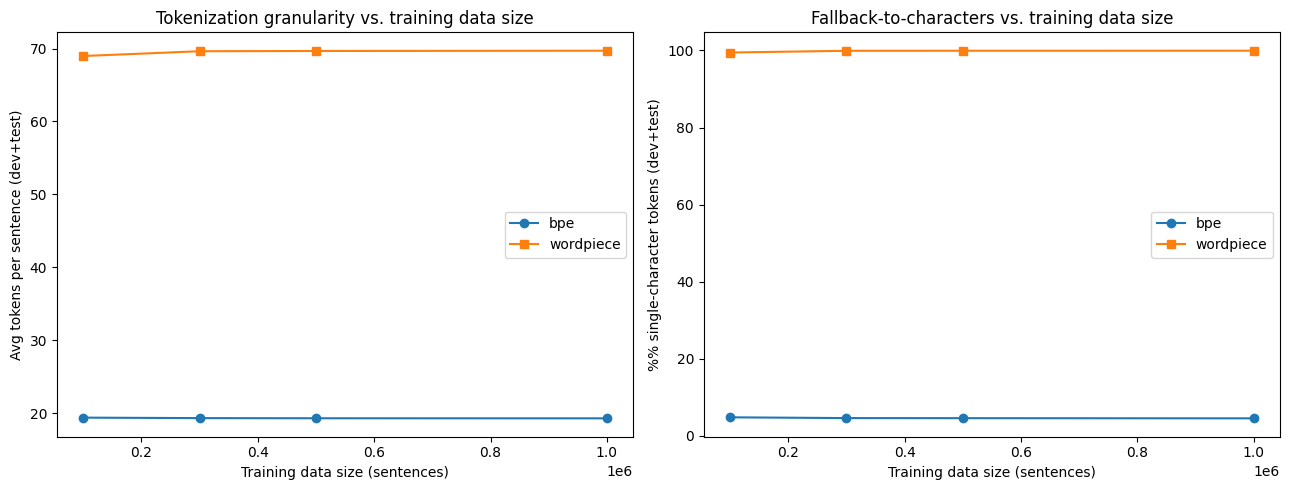

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for name, marker in [("bpe", "o"), ("wordpiece", "s")]:
    y_tok = [size_experiment_results[s][name]["avg_tokens_per_sentence"] for s in TRAIN_SIZES]
    y_char = [size_experiment_results[s][name]["pct_single_char_tokens"] for s in TRAIN_SIZES]
    axes[0].plot(TRAIN_SIZES, y_tok, marker=marker, label=name)
    axes[1].plot(TRAIN_SIZES, y_char, marker=marker, label=name)

axes[0].set_xlabel("Training data size (sentences)")
axes[0].set_ylabel("Avg tokens per sentence (dev+test)")
axes[0].set_title("Tokenization granularity vs. training data size")
axes[0].legend()

axes[1].set_xlabel("Training data size (sentences)")
axes[1].set_ylabel("%% single-character tokens (dev+test)")
axes[1].set_title("Fallback-to-characters vs. training data size")
axes[1].legend()

plt.tight_layout()
plt.show()


## 7. Experiment 2 — effect of vocabulary size

Training size held fixed at `FIXED_SIZE_FOR_VOCAB_EXPERIMENT`; vocab size varies
over `VOCAB_SIZES`.


In [12]:
vocab_experiment_results = {}
for vsize in VOCAB_SIZES:
    vocab_experiment_results[vsize] = run_config(FIXED_SIZE_FOR_VOCAB_EXPERIMENT, vsize)



=== Training size=500000, Vocab size=20000 ===


Training BPE:   0%|          | 0/19272 [00:00<?, ?it/s]

Training WordPiece:   0%|          | 0/18973 [00:00<?, ?it/s]

BPE       -> {'avg_tokens_per_sentence': 19.9735, 'avg_chars_per_token': np.float64(3.4959571432147594), 'pct_single_char_tokens': 5.770145442711593, 'achieved_vocab_size': 19926, 'num_merges': 19272}
WordPiece -> {'avg_tokens_per_sentence': 69.698, 'avg_chars_per_token': np.float64(1.0015925851530891), 'pct_single_char_tokens': 99.91678383884759, 'achieved_vocab_size': 6678, 'num_merges': 18973}

=== Training size=500000, Vocab size=50000 ===


Training BPE:   0%|          | 0/49272 [00:00<?, ?it/s]

Training WordPiece:   0%|          | 0/48973 [00:00<?, ?it/s]

BPE       -> {'avg_tokens_per_sentence': 18.6635, 'avg_chars_per_token': np.float64(3.7413400487582713), 'pct_single_char_tokens': 3.4505853671605005, 'achieved_vocab_size': 49376, 'num_merges': 49272}
WordPiece -> {'avg_tokens_per_sentence': 69.575, 'avg_chars_per_token': np.float64(1.0033632770391663), 'pct_single_char_tokens': 99.88645346748113, 'achieved_vocab_size': 14889, 'num_merges': 48973}


In [13]:
print(f"{'Vocab size':<14}{'Tokenizer':<12}{'Achv. vocab':<14}{'Avg tok/sent':<14}{'Avg chars/tok':<15}{'%% single-char':<14}")
print("-" * 82)
for vsize in VOCAB_SIZES:
    for name in ["bpe", "wordpiece"]:
        s = vocab_experiment_results[vsize][name]
        print(f"{vsize:<14}{name:<12}{s['achieved_vocab_size']:<14}"
              f"{s['avg_tokens_per_sentence']:<14.2f}{s['avg_chars_per_token']:<15.2f}"
              f"{s['pct_single_char_tokens']:<14.2f}")


Vocab size    Tokenizer   Achv. vocab   Avg tok/sent  Avg chars/tok  %% single-char
----------------------------------------------------------------------------------
20000         bpe         19926         19.97         3.50           5.77          
20000         wordpiece   6678          69.70         1.00           99.92         
30000         bpe         29785         19.30         3.62           4.62          
30000         wordpiece   9386          69.66         1.00           99.91         
50000         bpe         49376         18.66         3.74           3.45          
50000         wordpiece   14889         69.58         1.00           99.89         


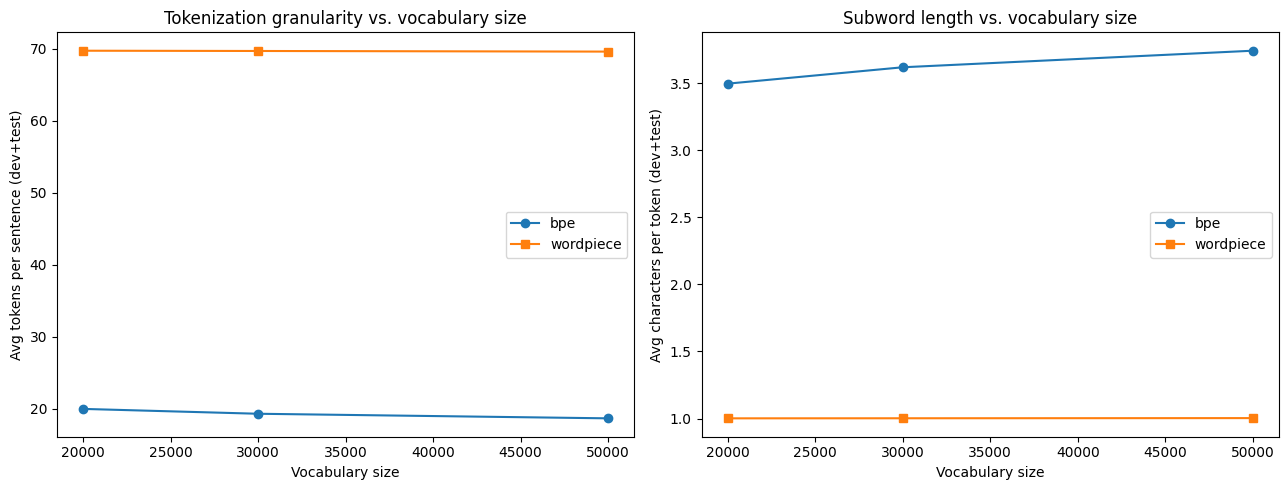

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for name, marker in [("bpe", "o"), ("wordpiece", "s")]:
    y_tok = [vocab_experiment_results[v][name]["avg_tokens_per_sentence"] for v in VOCAB_SIZES]
    y_char = [vocab_experiment_results[v][name]["avg_chars_per_token"] for v in VOCAB_SIZES]
    axes[0].plot(VOCAB_SIZES, y_tok, marker=marker, label=name)
    axes[1].plot(VOCAB_SIZES, y_char, marker=marker, label=name)

axes[0].set_xlabel("Vocabulary size")
axes[0].set_ylabel("Avg tokens per sentence (dev+test)")
axes[0].set_title("Tokenization granularity vs. vocabulary size")
axes[0].legend()

axes[1].set_xlabel("Vocabulary size")
axes[1].set_ylabel("Avg characters per token (dev+test)")
axes[1].set_title("Subword length vs. vocabulary size")
axes[1].legend()

plt.tight_layout()
plt.show()


## 8. Qualitative check — see the actual tokens

Numbers are useful, but it's worth eyeballing real tokenized sentences to sanity
check both tokenizers before writing up your observations.


In [15]:
# Reuse the largest already-trained config (by vocab size, then by training size)
# instead of retraining BPE/WordPiece a 7th time just for this demo.
example_key = max(results_cache.keys(), key=lambda k: (k[1], k[0]))
print("Showing tokenization examples for config (train_size, vocab_size):", example_key)

bpe_demo = results_cache[example_key]["bpe_model"]
wp_demo = results_cache[example_key]["wp_model"]
wp_demo_vocab = results_cache[example_key]["wp_vocab"]

for s in dev_sentences[:3]:
    print("\nSentence:", s)
    print("BPE       :", bpe_demo.tokenize_sentence(s))
    print("WordPiece :", wp_demo.tokenize_sentence(s, wp_demo_vocab))


Showing tokenization examples for config (train_size, vocab_size): (500000, 50000)

Sentence: चीन के एक ग्रुप ने प्राचीन बुद्ध की मूर्ति के साथ फोटो लेने के लिए ऐसी ही शर्मनाक हरकत कर डाली
BPE       : ['चीन</w>', 'के</w>', 'एक</w>', 'ग्रुप</w>', 'ने</w>', 'प्राचीन</w>', 'बुद्ध</w>', 'की</w>', 'मूर्ति</w>', 'के</w>', 'साथ</w>', 'फोटो</w>', 'लेने</w>', 'के</w>', 'लिए</w>', 'ऐसी</w>', 'ही</w>', 'शर्मनाक</w>', 'हरकत</w>', 'कर</w>', 'डाली</w>']
WordPiece : ['च', '##ी', '##न', 'क', '##े', 'ए', '##क', 'ग', '##्', '##र', '##ु', '##प', 'न', '##े', 'प', '##्', '##र', '##ा', '##च', '##ी', '##न', 'ब', '##ु', '##द', '##्', '##ध', 'क', '##ी', 'म', '##ू', '##र', '##्', '##त', '##ि', 'क', '##े', 'स', '##ा', '##थ', 'फ', '##ो', '##ट', '##ो', 'ल', '##े', '##न', '##े', 'क', '##े', 'ल', '##ि', '##ए', 'ऐ', '##स', '##ी', 'ह', '##ी', 'श', '##र', '##्', '##म', '##न', '##ा', '##क', 'ह', '##र', '##क', '##त', 'क', '##र', 'ड', '##ा', '##ल', '##ी']

Sentence: परिवार ने आज गृह मंत्री राजनाथ सिंह से मुलाकात भी की है
